# **Discretization (Binning)**

This notebook demonstrates how converting continuous numerical features into bins affects a machine learning model on the Titanic dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [ ]:
df = pd.read_csv('/content/Titanic-Dataset.csv',usecols = ['Age','Fare','Survived'])

In [ ]:
df.dropna(inplace= True)

In [ ]:
df.shape

(714, 3)

In [ ]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
X = df.iloc[:,1:]
y = df.iloc[:,0]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [ ]:
mod = LogisticRegression()

In [ ]:
mod.fit(X_train,y_train)
y_pred = mod.predict(X_test)

 The Accuracy without any binning

In [ ]:
accuracy_score(y_test,y_pred)

0.6293706293706294

In [ ]:
kbin_age = KBinsDiscretizer(n_bins=15,encode ='onehot-dense',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins = 15,encode ='onehot-dense',strategy = 'quantile')

In [ ]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [ ]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [ ]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [ ]:
trf.named_transformers_['second'].bin_edges_

array([array([  0.    ,   7.25  ,   7.775 ,   7.8958,   8.1583,  10.5   ,
               13.    ,  14.4542,  18.75  ,  26.    ,  26.55  ,  31.275 ,
               51.4792,  76.2917, 108.9   , 512.3292])                   ],
      dtype=object)

In [ ]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [ ]:
output.sample(5)

,age,age_trf,fare,fare_trf
472,33.0,0.0,27.7500,0.0
211,35.0,0.0,21.0000,0.0
373,22.0,0.0,135.6333,0.0
641,24.0,0.0,69.3000,0.0
875,15.0,0.0,7.2250,1.0


In [ ]:
mod = LogisticRegression()
mod.fit(X_train_trf,y_train)
y_pred2 = mod.predict(X_test_trf)

In [ ]:
accuracy_score(y_test,y_pred2)

0.6643356643356644

### **Observation**

• Age and Fare were converted into discrete bins using the Quantile strategy.

• Logistic Regression achieved nearly the same cross-validation accuracy after discretization.

• In this dataset, discretization did not provide a noticeable performance improvement.

• This experiment shows that feature engineering techniques should be evaluated empirically, as their effectiveness depends on the dataset and the learning algorithm.

## General Formula


In [ ]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)

    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])

    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(LogisticRegression(),X,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()


0.6554577464788732


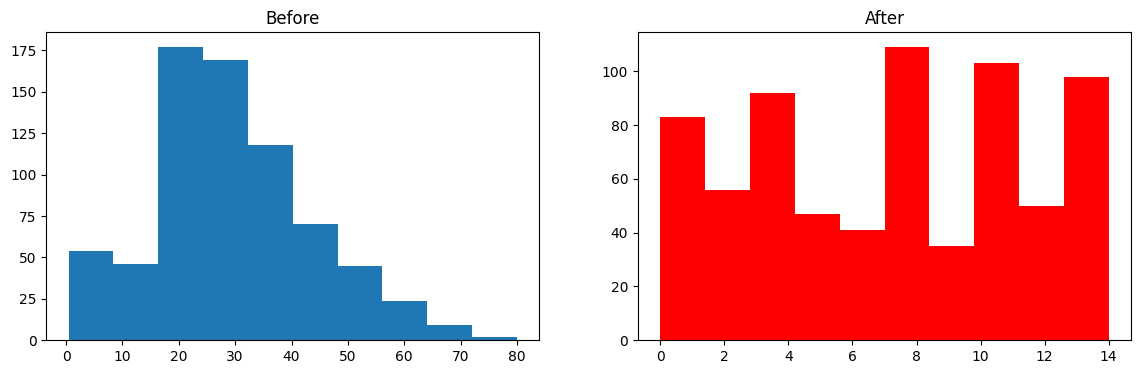

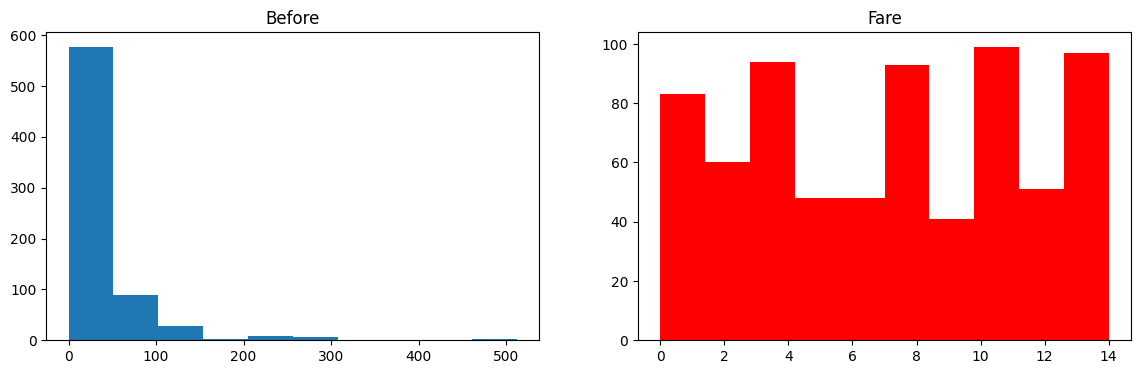

In [ ]:
discretize(15,'quantile')

# **Binarization**

This section converts numerical values into binary values using a threshold and compares model performance before and after preprocessing.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer

In [ ]:
df = pd.read_csv('/content/Titanic-Dataset.csv')[['Age','Fare','SibSp','Parch','Survived']]

In [ ]:
df.dropna(inplace=True)


In [ ]:
df.head()

,Age,Fare,SibSp,Parch,Survived
0,22.0,7.2500,1,0,0
1,38.0,71.2833,1,0,1
2,26.0,7.9250,0,0,1
3,35.0,53.1000,1,0,1
4,35.0,8.0500,0,0,0


In [ ]:
df['family'] = df['SibSp'] + df['Parch']

In [ ]:
df.drop(columns=['SibSp','Parch'],inplace=True)


In [ ]:
df.head()

,Age,Fare,Survived,family
0,22.0,7.2500,0,1
1,38.0,71.2833,1,1
2,26.0,7.9250,1,0
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [ ]:
X = df.drop(columns=['Survived'])
y = df['Survived']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
# Without binarization
clf = DecisionTreeClassifier()
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.6363636363636364

In [ ]:
# Applying Binarization
from sklearn.preprocessing import Binarizer

In [ ]:
trf = ColumnTransformer([
    ('bin',Binarizer(copy=False),['family'])
],remainder='passthrough')


In [ ]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)


In [ ]:
pd.DataFrame(X_train_trf,columns=['family','Age','Fare'])

,family,Age,Fare
0,1.0,31.0,20.5250
1,1.0,26.0,14.4542
2,1.0,30.0,16.1000
3,0.0,33.0,7.7750
4,0.0,25.0,13.0000
...,...,...,...
566,1.0,46.0,61.1750
567,0.0,25.0,13.0000
568,0.0,41.0,134.5000
569,1.0,33.0,20.5250


In [ ]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

accuracy_score(y_test,y_pred2)

0.6293706293706294

### **Observation**

- The numerical feature was converted into binary values using a threshold.

- The Decision Tree model achieved slightly lower accuracy after binarization.

- In this dataset, binarization did not improve model performance and resulted in a small loss of predictive information.

- This experiment demonstrates that binarization should be applied only when it aligns with the nature of the data and the requirements of the machine learning algorithm.

## Why didn't accuracy improve?

Preprocessing techniques are not guaranteed to improve every dataset.

Discretization and binarization can sometimes reduce useful information. The goal of this notebook is to understand when these preprocessing techniques are useful rather than assuming they always increase accuracy.

# Conclusion

In this notebook I experimented with two preprocessing techniques:

• Discretization (Binning)

• Binarization

Both techniques were evaluated by training machine learning models before and after preprocessing.

Result:

- Discretization produced similar performance.
- Binarization slightly reduced accuracy.

This experiment demonstrates that preprocessing should always be validated experimentally rather than assumed to improve a model.